In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff

In [2]:
dim = 1
M = 1e-2
p = 4
v0 = 1.7e-14 * M ** 4 # 多田さんのノートの式

def infPotFunc(phi):
    x = phi / M
    return float(v0 * (1 - x ** p) ** 2)

def infPotDerivFunc(phi):
    x = phi / M
    return float(-2 * p * v0 / M * (1 - x ** p) * x ** (p - 1))

def infPotDeriv2Func(phi):
    x = phi / M
    return float(2 * p * v0 / M / M * ((2 * p - 1) * x ** p - p + 1) * x ** (p - 2))

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 512
upperBound = (M * M / 2 / p / (p - 1)) ** (1 / (p - 2)) * M
lowerBound = ((p - 1) * v0 / 2 / p) ** (1 / p) * M * 0.001 # v''=(v'/v)^2 となる点の1/1000

In [3]:
fpFinDiff = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Neumann0"],
    logGrid=True
)

In [4]:
fpFinDiff[:10, :10]

array([[ 2.58954129, -2.58954129,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [-1.24448913,  2.45661445, -1.21212533,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -1.18060677,  2.33051104, -1.14990427,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -1.12000363,  2.2108808 , -1.09087717,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -1.06251139,  2.09739144,
        -1.03488005,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -1.00797035,
         1.98972773, -0.98175738,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.95622902,  1.88759064, -0.93136162

In [5]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
eigVecsSort = eigVecs.T[np.argsort(eigVals)]
eigValsSort = np.sort(eigVals)

In [6]:
import matplotlib.pyplot as plt

In [7]:
nMode = np.arange(1, nGrid + 1)
eigValsFlat = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) ** 2 * n ** 2 for n in nMode]

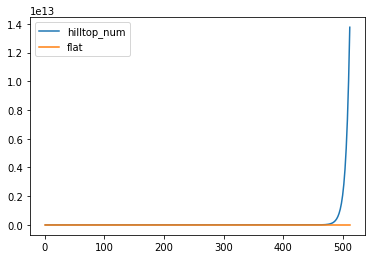

In [8]:
ax = plt.gca()
plt.plot(nMode, eigValsSort, label = "hilltop_num")
plt.plot(nMode, eigValsFlat, label = "flat")
plt.legend()
plt.show()

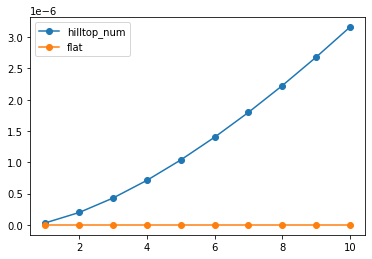

In [9]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort[:10], marker='o', label = "hilltop_num")
plt.plot(np.arange(1, 11), eigValsFlat[:10], marker='o', label = "flat")
plt.legend()
plt.show()

In [10]:
print(eigValsSort[:10])
print(eigValsFlat[:10])

[3.30197187e-08 1.98799589e-07 4.29413889e-07 7.11637901e-07
 1.03697585e-06 1.39989201e-06 1.79633006e-06 2.22309644e-06
 2.67754782e-06 3.15741318e-06]
[1.700004706580455e-14, 6.80001882632182e-14, 1.5300042359224096e-13, 2.720007530528728e-13, 4.2500117664511373e-13, 6.120016943689638e-13, 8.330023062244229e-13, 1.0880030122114912e-12, 1.3770038123301685e-12, 1.700004706580455e-12]


考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [11]:
gridEx = np.exp(np.linspace(np.log(lowerBound), np.log(upperBound), nGrid+1, endpoint=True)[:-1])
sigma = upperBound / 3.0
trialVec = np.exp(- 0.5 * (gridEx / sigma) ** 2)

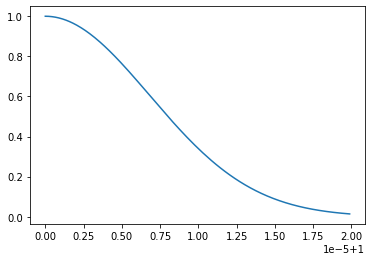

In [12]:
ax = plt.gca()
plt.plot(np.exp(gridEx), trialVec)
plt.show()

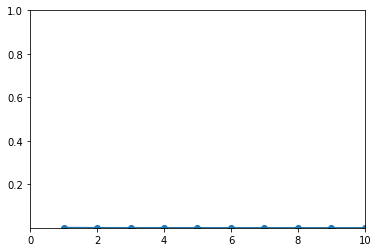

In [13]:
# 各固有ベクトルの寄与度
contriEachEigVec = []
trialVecNorm = np.sum([trialVec[i] * trialVec[i] * (gridEx[i+1] - gridEx[i]) for i in range(nGrid - 1)])
for ev in eigVecsSort:
    integ = np.sum([ev[i] * trialVec[i] * (gridEx[i+1] - gridEx[i]) for i in range(nGrid - 1)])
    evNorm = np.sum([ev[i] * ev[i] * (gridEx[i+1] - gridEx[i]) for i in range(nGrid - 1)])
    contriEachEigVec.append(integ ** 2 / evNorm / trialVecNorm)

ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

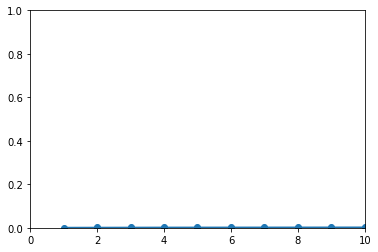

In [14]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()

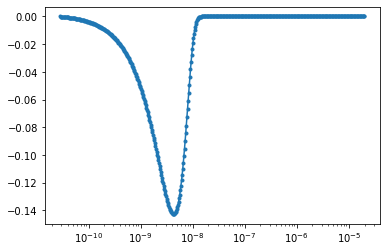

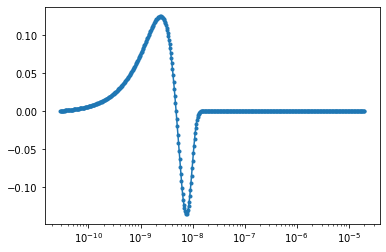

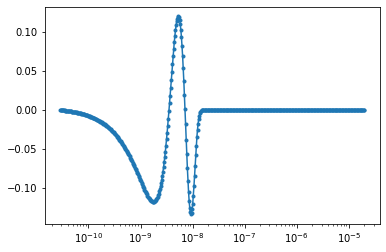

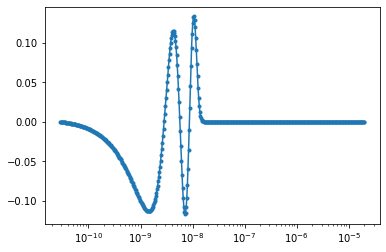

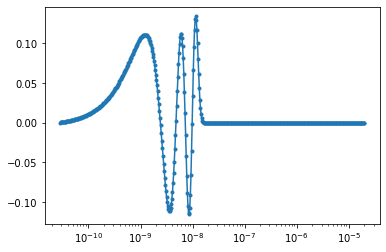

In [23]:
# 固有関数のプロット
ax = plt.gca()

for iEig in range(5):
    plt.plot(gridEx, eigVecsSort[iEig],marker='.')
    plt.xscale("log")
    plt.show()

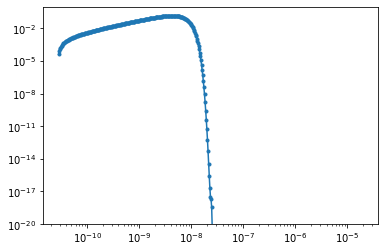

In [25]:
# 最小固有値の固有関数の絶対値の両対数プロット
ax = plt.gca()
plt.plot(gridEx, np.abs(eigVecsSort[0]), marker='.')
plt.xscale("log")
plt.yscale("log")
ax.set_ylim(1e-20, 1)
plt.show()